<div align="center">

# Projet de fin de module — Data Engineering

## Sujet 3 — Santé publique : suivi épidémiologique au CHU d'Abidjan

### Construction d'un entrepôt épidémiologique pour le CHU de Treichville

---

| Nom et prénoms |  

| *KOUAME GUY MARC AXEL* | 

**Sujet :** n° 3 — Santé publique, suivi épidémiologique au CHU d'Abidjan

**Dépôt GitHub :** *https://github.com/Vxell/projet-de-chu-treichville.git*

**Enseignant :** GOUAH Tato Serge — Module Data Engineering

---
</div>

## Objet du notebook

Ce notebook exécute la totalité du pipeline, de la lecture du fichier brut issu du
système d'information hospitalier jusqu'au tableau de bord épidémiologique, en
passant par la pseudonymisation réglementaire, le chargement dans Supabase et la
modélisation en étoile.

Il s'exécute intégralement (`Kernel → Restart & Run All`) sans intervention
manuelle. Lorsque la connexion Supabase n'est pas configurée, les requêtes
analytiques sont rejouées sur un moteur SQL local afin que l'exécution reste
complète — le SQL exécuté est strictement identique.

## Sommaire

| Étape | Contenu |
|---|---|
| 0 | Configuration de l'environnement |
| 1 | Extraction et audit du fichier source |
| 2 | Nettoyage des données |
| 3 | Pseudonymisation (loi n° 2019-992) |
| 4 | Enrichissement métier |
| 5 | Contrôle qualité |
| 6 | Modélisation en étoile |
| 7 | Chargement dans Supabase |
| 8 | Analyses SQL |
| 9 | Tableau de bord |
| 10 | Synthèse et indicateurs clés |


---
# 0. Configuration de l'environnement

Le code métier est regroupé dans `src/` plutôt que recopié dans le notebook :
le DAG Airflow appelle exactement les mêmes fonctions, ce qui garantit que le
pipeline automatisé et le pipeline exploratoire produisent le même résultat.
Toute correction est ainsi appliquée aux deux à la fois.

In [ ]:
import os
import subprocess
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# --- Localisation de la racine du projet -------------------------------------
# Fonctionne aussi bien depuis notebooks/ (exécution locale) que depuis un
# environnement vierge type Google Colab, où le dépôt est cloné à la volée.
DEPOT = "https://github.com/Vxell/projet-de-chu-treichville.git"

racine = Path.cwd()
if not (racine / "src").exists():
    if (racine.parent / "src").exists():
        racine = racine.parent
    else:
        subprocess.run(["git", "clone", DEPOT, "projet"], check=True)
        racine = Path.cwd() / "projet"
os.chdir(racine)
sys.path.insert(0, str(racine / "src"))

print("Racine du projet :", racine)

Racine du projet : /app


In [2]:
# --- Chargement des secrets --------------------------------------------------
# Les identifiants ne figurent jamais dans le notebook : ils sont lus depuis
# un fichier .env exclu du dépôt Git.
try:
    from dotenv import load_dotenv
    load_dotenv(racine / ".env")
except ImportError:
    print("python-dotenv absent : les variables doivent être définies dans "
          "l'environnement.")

# Le sel de pseudonymisation doit rester constant d'une exécution à l'autre,
# sans quoi le même patient recevrait un pseudonyme différent à chaque
# chargement et le chaînage des séjours serait perdu. En son absence, on
# utilise une valeur de démonstration afin que le notebook reste exécutable,
# mais un déploiement réel exige un sel secret et stable.
if not os.environ.get("DE_SEL_PSEUDO"):
    os.environ["DE_SEL_PSEUDO"] = "sel_de_demonstration_a_remplacer"
    print("Sel de démonstration utilisé (voir .env.example pour la production).")

CHARGER_SUPABASE = bool(os.environ.get("SUPABASE_DB_URL"))
print("Chargement Supabase :", "activé" if CHARGER_SUPABASE else
      "désactivé (SUPABASE_DB_URL absente)")

Chargement Supabase : activé


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pipeline_etl as etl
from dashboard import generer_dashboard

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

FICHIER_SOURCE = racine / "data/raw/admissions_chu_treichville.csv"

# Le fichier source est généré si absent : le dépôt versionne le générateur
# (src/generate_dataset.py) et non les 25 Mo de CSV.
if not FICHIER_SOURCE.exists():
    print("Fichier source absent, génération en cours...")
    subprocess.run([sys.executable, "src/generate_dataset.py"], check=True,
                   cwd=racine)
    Path("admissions_chu_treichville.csv").rename(FICHIER_SOURCE)

print("Fichier source :", FICHIER_SOURCE.name,
      f"({FICHIER_SOURCE.stat().st_size / 1e6:.1f} Mo)")

Fichier source : admissions_chu_treichville.csv (24.7 Mo)


---
# 1. Extraction et audit du fichier source

## 1.1 Contexte

Le fichier provient d'une extraction du système d'information hospitalier du CHU
de Treichville, couvrant deux années d'admissions (2023-2024). Il s'agit d'un
export brut : aucun traitement n'a été appliqué en amont, ni sur la qualité, ni
sur la confidentialité.

Deux conséquences pour le pipeline :

1. Le fichier contient des **données directement identifiantes** (nom, prénom,
   téléphone, date de naissance) qui ne peuvent pas entrer dans un entrepôt
   analytique en l'état.
2. Il porte les **défauts de saisie** habituels d'un SIH alimenté par plusieurs
   dizaines d'agents : codifications divergentes, doublons, valeurs aberrantes,
   dossiers incomplets.

L'audit ci-dessous en dresse l'inventaire chiffré.

In [4]:
df_brut = etl.extraire(FICHIER_SOURCE)
df_brut.head(3)

Extraction : 122,400 lignes × 21 colonnes en 0.4 s


,id_admission,id_patient,nom_patient,prenom_patient,date_naissance,age,sexe,telephone,commune_residence,assurance,mode_admission,date_entree,date_sortie,duree_sejour_j,service,pathologie,gravite,id_medecin,temperature_entree_c,cout_hospitalisation_fcfa,issue
0,ADM0104625,PAT018669,Kouassi,Olivier,20/01/1973,50,M,+225 05 56 91 97 53,Yopougon,Aucune,Urgence,2023-02-15 18:09:00,2023-02-20 08:33:00,4.6,Cardiologie,Insuffisance cardiaque,Legere,MED065,37.1,201400,Gueri
1,ADM0027832,PAT022300,Toure,Rosine,08/09/1993,31,F,+225 01 25 39 60 37,Adjame,Aucune,Programmee,2024-11-22 21:06:00,2024-11-24 18:42:00,1.9,Medecine interne,Fievre typhoide,Legere,MED110,38.4,32200,Gueri
2,ADM0065698,PAT052748,N'Guessan,Herve,23/10/2015,7,M,+225 05 20 39 97 18,Yopougon,CMU,Transfert,2023-02-02 07:16:00,2023-02-07 02:28:00,4.8,Urgences,Brulure,Critique,MED030,37.1,112300,Gueri


In [5]:
# Indicateurs de synthèse : ils ouvrent la section 3 du rapport
resume = etl.resumer_audit(df_brut)
pd.Series(resume).to_frame("valeur")

,valeur
lignes,122400.00
colonnes,21.00
doublons_stricts,2400.00
id_admission_dupliques,2400.00
cellules_manquantes,24114.00
taux_manquant_global_%,0.94
memoire_Mo,136.00


In [6]:
# Audit détaillé colonne par colonne
audit = etl.auditer(df_brut)
audit

,type,valeurs_non_nulles,valeurs_manquantes,taux_manquant_%,valeurs_distinctes,exemple
id_admission,object,122400,0,0.00,120000,ADM0104625
id_patient,object,122400,0,0.00,96286,PAT018669
nom_patient,object,122400,0,0.00,44,Kouassi
prenom_patient,object,122400,0,0.00,49,Olivier
date_naissance,object,122400,0,0.00,28602,20/01/1973
age,int64,122400,0,0.00,101,50
sexe,object,121422,978,0.80,8,M
telephone,object,122400,0,0.00,96264,+225 05 56 91 97 53
commune_residence,object,122400,0,0.00,19,Yopougon
assurance,object,120072,2328,1.90,4,Aucune


## 1.2 Lecture de l'audit

Trois familles de problèmes ressortent.

**Complétude.** Plusieurs colonnes présentent des valeurs manquantes : la durée
de séjour (dossiers clos sans date de sortie), l'identifiant du médecin (séjours
non attribués), la température d'entrée (constante non relevée) et la couverture
maladie.

**Cardinalité anormale.** La colonne `pathologie` affiche un nombre de modalités
distinctes très supérieur aux 31 diagnostics du référentiel médical. L'écart
provient uniquement de variations de casse et d'espaces parasites. La colonne
`sexe` présente le même symptôme.

**Doublons.** Des lignes strictement identiques figurent dans l'export, signe
d'une double soumission du même formulaire dans le SIH.

Vérifions ce diagnostic sur les colonnes concernées.

In [7]:
print("Modalités de la colonne sexe :")
print(df_brut["sexe"].value_counts(dropna=False).to_string(), "\n")

print(f"Modalités distinctes de pathologie : {df_brut['pathologie'].nunique()} "
      f"(référentiel médical : 31)")
print("Exemples de variantes de la même pathologie :")
variantes = [v for v in df_brut["pathologie"].dropna().unique()
             if v.strip().lower() == "paludisme simple"]
print(" ", variantes, "\n")

print(f"Lignes strictement dupliquées : {df_brut.duplicated().sum():,}")

Modalités de la colonne sexe :
sexe
F           57168
M           46682
Feminin      5669
Masculin     4616
f            3643
m            2998
NaN           978
feminin       337
masculin      309 

Modalités distinctes de pathologie : 123 (référentiel médical : 31)
Exemples de variantes de la même pathologie :
  ['Paludisme simple', 'PALUDISME SIMPLE', '  Paludisme simple ', '  PALUDISME SIMPLE '] 

Lignes strictement dupliquées : 2,400


---
# 2. Nettoyage des données

## 2.1 Principes retenus

Le nettoyage suit un ordre imposé par les dépendances entre opérations : on ne
peut pas détecter une valeur aberrante avant d'avoir converti la colonne en
numérique, ni normaliser un libellé après avoir groupé dessus.

| Ordre | Opération | Principe |
|---|---|---|
| 1 | Dédoublonnage | Supprimer avant de compter quoi que ce soit |
| 2 | Normalisation des libellés | Rattacher chaque valeur à son référentiel |
| 3 | Conversion des types | `errors='coerce'` : l'échec devient un NaN traçable |
| 4 | Valeurs aberrantes | Neutralisées en NaN, ligne conservée |
| 5 | Incohérences inter-colonnes | Reconstruction quand une autre colonne le permet |
| 6 | Imputation | Médiane **par pathologie**, jamais médiane globale |

Deux décisions méritent d'être défendues.

**Neutraliser plutôt que supprimer.** Un âge saisi à 999 n'invalide pas
l'admission : le séjour a eu lieu, sa durée et son coût restent exploitables.
Supprimer la ligne détruirait de l'information valide pour corriger une seule
cellule.

**Imputer par pathologie.** Un séjour pour accouchement dure environ 2 jours, un
séjour pour AVC hémorragique 14. Imputer une médiane globale de 5 jours partout
biaiserait systématiquement les deux extrémités de la distribution et fausserait
toute analyse de durée moyenne de séjour.

In [8]:
df_propre = etl.nettoyer(df_brut)
journal = pd.DataFrame(etl.JOURNAL)
journal

,etape,lignes_avant,lignes_apres,delta,detail
0,Extraction du fichier source,122400,122400,0,admissions_chu_treichville.csv
1,Suppression des doublons,122400,120000,-2400,"2400 doublons stricts, 0 id_admission dupliqués"
2,Normalisation des libellés,120000,120000,0,0 pathologies hors référentiel
3,Conversion des types,120000,120000,0,"dates, numériques, identifiants"
4,Neutralisation des valeurs aberrantes,120000,120000,0,"age: 1065, duree_sejour_j: 1080, temperature_e..."
5,Correction des incohérences,120000,120000,0,"902 chronologies inversées, 6780 durées recons..."
6,Imputation,120000,120000,0,"476 durées (médiane par pathologie), 1065 âges..."


## 2.2 Effet mesuré du nettoyage

Le tableau ci-dessous compare l'état des colonnes avant et après traitement.

In [9]:
comparaison = pd.DataFrame({
    "modalités avant": [df_brut[c].nunique() for c in
                        ["sexe", "pathologie", "service", "commune_residence"]],
    "modalités après": [df_propre[c].nunique() for c in
                        ["sexe", "pathologie", "service", "commune_residence"]],
}, index=["sexe", "pathologie", "service", "commune_residence"])
comparaison["référentiel"] = [3, 31, 8, 13]
comparaison

,modalités avant,modalités après,référentiel
sexe,8,3,3
pathologie,123,31,31
service,8,8,8
commune_residence,19,13,13


---
# 3. Pseudonymisation — loi ivoirienne n° 2019-992

## 3.1 Obligation applicable

Les données de santé relèvent de la catégorie des données sensibles au sens de
la loi n° 2019-992 relative à la protection des données à caractère personnel.
Un entrepôt analytique n'a besoin d'aucune donnée identifiante : le principe de
minimisation impose de les retirer avant tout chargement.

## 3.2 Trois traitements pour trois natures de données

| Donnée | Traitement | Justification |
|---|---|---|
| `id_patient` | Hachage SHA-256 **salé** | Conserve le chaînage des séjours d'un même patient sans conserver son identifiant |
| `nom`, `prénom`, `téléphone` | Suppression | Aucune valeur analytique — minimisation |
| `date_naissance` | Généralisation à l'année | Quasi-identifiant : la date exacte croisée avec commune et sexe réidentifie |

**Pourquoi le sel est indispensable.** L'espace des identifiants patients
(`PAT000001` à `PAT120000`) compte moins de 120 000 valeurs. Sans sel, un
attaquant disposant de la table hachée reconstruirait la correspondance complète
en quelques secondes par force brute. Le sel, conservé hors du dépôt, rend cette
attaque impraticable.

**Pseudonymisation, pas anonymisation.** Le traitement reste réversible pour qui
détient le sel. C'est le régime attendu ici : le CHU doit pouvoir remonter au
dossier patient en cas d'alerte sanitaire. Une anonymisation véritable
interdirait ce retour et supprimerait l'intérêt d'un entrepôt épidémiologique
opérationnel.

In [10]:
df_pseudo, audit_rgpd = etl.pseudonymiser(df_propre)
audit_rgpd[["colonne", "operation", "justification"]]

Pseudonymisation : 5 traitements appliqués sur 120,000 lignes


,colonne,operation,justification
0,id_patient,Hachage SHA-256 salé,Chaînage des séjours conservé sans identifiant...
1,nom_patient,Suppression,Aucune valeur analytique (minimisation)
2,prenom_patient,Suppression,Aucune valeur analytique (minimisation)
3,telephone,Suppression,Aucune valeur analytique (minimisation)
4,date_naissance,Généralisation (année seule),Quasi-identifiant : date exacte réidentifiante


In [11]:
# Contrôle : plus aucune donnée directement identifiante ne subsiste
colonnes_sensibles = ["nom_patient", "prenom_patient", "telephone",
                      "date_naissance", "id_patient"]
print("Colonnes identifiantes restantes :",
      [c for c in colonnes_sensibles if c in df_pseudo.columns] or "aucune")

etl.verifier_absence_donnees_personnelles(df_pseudo)
print("Contrôle de conformité : validé\n")

# Le chaînage des séjours est bien préservé après hachage
sejours = df_pseudo["id_patient_pseudo"].value_counts()
print(f"Patients distincts        : {len(sejours):,}")
print(f"Séjours par patient (max) : {sejours.max()}")
print(f"Patients réhospitalisés   : {(sejours > 1).sum():,} "
      f"({100 * (sejours > 1).mean():.1f} %)")

Colonnes identifiantes restantes : aucune
Contrôle de conformité : validé

Patients distincts        : 96,286
Séjours par patient (max) : 12
Patients réhospitalisés   : 18,603 (19.3 %)


---
# 4. Enrichissement métier

Sept colonnes calculées sont ajoutées. Chacune répond à une question que la
direction de l'établissement se pose et qu'aucune colonne source ne permet de
traiter directement.

| Colonne | Question à laquelle elle répond |
|---|---|
| `tranche_age` | Quelles classes d'âge concentrent l'activité et la mortalité ? |
| `saison` | L'activité suit-elle le calendrier des pluies ? |
| `categorie_pathologie` | Comment lire 31 diagnostics sur un seul graphique ? |
| `cout_journalier_fcfa` | Quel service coûte le plus cher **à durée égale** ? |
| `sejour_prolonge` | Quels séjours dépassent la norme **de leur service** ? |
| `delai_readmission_j` | Combien de temps s'écoule avant le retour d'un patient ? |
| `est_readmission_30j` | Indicateur international de qualité des soins |

Le seuil du séjour prolongé est relatif au service : 12 jours sont normaux en
neurologie et anormaux en maternité. Un seuil unique classerait tout un service
en anomalie.

In [12]:
df_enrichi = etl.enrichir(df_pseudo)

nouvelles = ["tranche_age", "saison", "categorie_pathologie",
             "cout_journalier_fcfa", "sejour_prolonge",
             "delai_readmission_j", "est_readmission_30j"]
df_enrichi[nouvelles].head(5)

Enrichissement : 7 colonnes calculées ajoutées (27 colonnes au total)


,tranche_age,saison,categorie_pathologie,cout_journalier_fcfa,sejour_prolonge,delai_readmission_j,est_readmission_30j
0,45-64 ans (adulte),Saison sèche,Traumatologie et chirurgie,46769.0,False,NaN,False
1,25-44 ans (adulte jeune),Saison sèche,Santé maternelle,58444.0,False,NaN,False
2,5-14 ans (enfance),Saison sèche,Maladie infectieuse,28081.0,False,NaN,False
3,25-44 ans (adulte jeune),Saison sèche,Santé maternelle,28490.0,False,NaN,False
4,25-44 ans (adulte jeune),Saison sèche,Maladie chronique non transmissible,38952.0,False,NaN,False


In [13]:
# Vérification que l'enrichissement produit bien de l'information exploitable
print("Répartition par catégorie de pathologie :")
print((df_enrichi["categorie_pathologie"].value_counts(normalize=True) * 100)
      .round(1).to_string(), "\n")

print("Admissions par saison :")
print(df_enrichi["saison"].value_counts().to_string(), "\n")

print(f"Séjours prolongés    : {df_enrichi['sejour_prolonge'].sum():,} "
      f"({100 * df_enrichi['sejour_prolonge'].mean():.1f} %)")
print(f"Réadmissions à 30 j  : {df_enrichi['est_readmission_30j'].sum():,} "
      f"({100 * df_enrichi['est_readmission_30j'].mean():.2f} %)")

Répartition par catégorie de pathologie :
categorie_pathologie
Maladie infectieuse                    38.2
Maladie chronique non transmissible    27.4
Traumatologie et chirurgie             18.8
Santé maternelle                       13.2
Néonatalogie et nutrition               2.4 

Admissions par saison :
saison
Grande saison des pluies    42421
Saison sèche                37798
Petite saison des pluies    20312
Petite saison sèche         19469 

Séjours prolongés    : 11,901 (9.9 %)
Réadmissions à 30 j  : 2,479 (2.07 %)


---
# 5. Contrôle qualité

Huit règles de validation sont appliquées avant tout chargement. Six sont
**bloquantes** : leur échec interrompt le pipeline.

La distinction n'est pas cosmétique. Une règle bloquante porte sur l'intégrité
du modèle ou sur la conformité réglementaire — charger malgré son échec
produirait un entrepôt faux ou illégal. Une règle informative signale une
dégradation de la complétude : l'analyse en souffre mais reste juste, à
condition que le défaut soit documenté.

| Règle | Nature | Motif |
|---|---|---|
| R1 — Unicité de `id_admission` | Bloquante | Clé primaire de la table de faits |
| R2 — Absence de données personnelles | Bloquante | Loi n° 2019-992 |
| R3 — Âge dans [0 ; 110] | Bloquante | Contrainte `CHECK` en base |
| R4 — Durée de séjour positive | Bloquante | Mesure additive du modèle |
| R5 — Cohérence entrée/sortie | Bloquante | Incohérence temporelle |
| R6 — Issue conforme au référentiel | Bloquante | Intégrité de `dim_issue` |
| R7 — Pathologie rattachée | Informative | Exclusion des analyses par diagnostic |
| R8 — Complétude de la température | Informative | Constante non relevée |

In [14]:
rapport_qualite = etl.controler_qualite(df_enrichi, bloquant=True)
rapport_qualite

Contrôle qualité : 7/8 règles satisfaites


,regle,violations,statut,criticite,message
0,R1 — Unicité de id_admission,0,OK,bloquante,
1,R2 — Absence de données personnelles,0,OK,bloquante,
2,R3 — Âge dans une plage plausible,0,OK,bloquante,
3,R4 — Durée de séjour strictement positive,0,OK,bloquante,
4,R5 — Cohérence chronologique entrée/sortie,0,OK,bloquante,
5,R6 — Issue conforme au référentiel,0,OK,bloquante,
6,R7 — Pathologie rattachée au référentiel,0,OK,informative,
7,R8 — Complétude de la température,4061,AVERTISSEMENT,informative,4061 températures non relevées (4061 dossiers ...


---
# 6. Modélisation en étoile

## 6.1 Choix de modélisation

**Grain de la table de faits : une ligne = une admission hospitalière.**
Le grain est le choix structurant du modèle. Un grain plus fin (une ligne par
journée d'hospitalisation) permettrait des analyses d'occupation au jour près,
au prix d'une multiplication du volume par la durée moyenne de séjour — environ
850 000 lignes. Le grain « admission » suffit à tous les besoins exprimés :
l'occupation se calcule en sommant les durées.

**Étoile plutôt que flocon.** Les dimensions sont volontairement dénormalisées :
`dim_pathologie` porte sa catégorie, `dim_date` porte sa saison. La redondance
est négligeable — 31 lignes — et chaque requête analytique économise une
jointure.

**Clés techniques entières.** Les dimensions sont identifiées par une clé
technique et non par leur libellé : les jointures sur entier sont plus rapides,
et une correction de libellé n'oblige pas à réécrire la table de faits.

**`id_patient_pseudo` en dimension dégénérée.** Une dimension patient ne
porterait aucun attribut — tous ont été supprimés ou généralisés — et
constituerait un point de concentration de données sensibles sans contrepartie
analytique.

## 6.2 Structure

```
                     ┌──────────────┐
                     │   dim_date   │  731 jours
                     └──────┬───────┘
   ┌──────────────┐         │         ┌────────────────┐
   │ dim_service  ├─────────┼─────────┤ dim_pathologie │
   └──────────────┘         │         └────────────────┘
                   ┌────────┴─────────┐
                   │ faits_admissions │  120 000 lignes
                   └────────┬─────────┘
   ┌──────────────┐         │         ┌────────────────┐
   │ dim_commune  ├─────────┼─────────┤  dim_issue     │
   └──────────────┘         │         └────────────────┘
                     ┌──────┴────────┐
                     │dim_tranche_age│
                     └───────────────┘
```

## 6.3 Ordre de construction

Les dimensions sont construites et peuplées **avant** la table de faits. Les
clés étrangères sont ensuite résolues par dictionnaires de correspondance, et
leur intégrité est vérifiée avant restitution : une seule clé non résolue
provoquerait un échec d'insertion dans PostgreSQL après plusieurs minutes de
chargement.

In [15]:
dimensions = etl.construire_dimensions(df_enrichi)

  dim_date                731 lignes
  dim_service               8 lignes
  dim_pathologie           31 lignes
  dim_tranche_age           7 lignes
  dim_commune              13 lignes
  dim_issue                 4 lignes


In [16]:
dimensions["dim_pathologie"].head(8)

,pathologie_id,libelle_pathologie,categorie
0,1,AVC hémorragique,Maladie chronique non transmissible
1,2,AVC ischémique,Maladie chronique non transmissible
2,3,Accouchement eutocique,Santé maternelle
3,4,Anémie sévère,Maladie chronique non transmissible
4,5,Appendicite aiguë,Traumatologie et chirurgie
5,6,Brûlure,Traumatologie et chirurgie
6,7,Covid-19,Maladie infectieuse
7,8,Césarienne,Santé maternelle


In [17]:
faits = etl.construire_faits(df_enrichi, dimensions)
faits.head(3)

  faits_admissions     120000 lignes, 6 clés étrangères toutes résolues


,id_admission,date_id,service_id,pathologie_id,tranche_id,commune_id,issue_id,id_patient_pseudo,sexe,age,annee_naissance,mode_admission,gravite,assurance,id_medecin,heure_admission,duree_sejour_j,cout_hospitalisation_fcfa,cout_journalier_fcfa,temperature_entree_c,sejour_prolonge,est_readmission_30j,delai_readmission_j,duree_imputee
0,ADM0115072,20230101,2,28,5,2,2,71a5794f67bb5627,M,45.0,1977,Urgence,Moderee,Aucune,MED046,0,9.1,425600.0,46769.0,36.7,False,False,NaN,False
1,ADM0117936,20230101,4,3,4,2,2,7dd41757725717bd,F,28.0,1994,Urgence,Legere,Mutuelle employeur,MED039,0,0.9,52600.0,58444.0,36.8,False,False,NaN,False
2,ADM0089541,20230101,8,25,2,10,2,6dd7c735c370583d,M,10.0,2012,Urgence,Severe,Aucune,MED_INCONNU,0,3.7,103900.0,28081.0,39.9,False,False,NaN,False


In [18]:
# Contrôle d'intégrité référentielle avant chargement
fks = {"date_id": "dim_date", "service_id": "dim_service",
       "pathologie_id": "dim_pathologie", "tranche_id": "dim_tranche_age",
       "commune_id": "dim_commune", "issue_id": "dim_issue"}

controle = []
for fk, dim in fks.items():
    cle_dim = set(dimensions[dim][fk])
    orphelines = set(faits[fk]) - cle_dim
    controle.append({"clé étrangère": fk, "dimension": dim,
                     "valeurs nulles": int(faits[fk].isna().sum()),
                     "valeurs orphelines": len(orphelines)})
pd.DataFrame(controle)

,clé étrangère,dimension,valeurs nulles,valeurs orphelines
0,date_id,dim_date,0,0
1,service_id,dim_service,0,0
2,pathologie_id,dim_pathologie,0,0
3,tranche_id,dim_tranche_age,0,0
4,commune_id,dim_commune,0,0
5,issue_id,dim_issue,0,0


---
# 7. Chargement dans Supabase

Le chargement respecte l'ordre imposé par les contraintes d'intégrité :
dimensions d'abord, table de faits ensuite.

**Optimisation du chargement.** L'insertion ligne à ligne de 120 000
enregistrements dépasse la vingtaine de minutes et rend le notebook
inexploitable. Deux paramètres corrigent cela :

- `method="multi"` regroupe les lignes en insertions multi-valeurs ;
- `chunksize=5000` borne la taille de chaque requête pour rester sous la limite
  de paramètres du driver PostgreSQL.

**Index posés après le chargement.** Maintenir les index pendant l'insertion
multiplierait le temps de traitement : chaque ligne insérée déclencherait une
mise à jour de l'arbre.

La transaction est explicitement validée par `conn.commit()` et le pool de
connexions libéré par `engine.dispose()`.

In [19]:
if CHARGER_SUPABASE:
    moteur = etl.obtenir_moteur()
    durees = etl.charger_entrepot(dimensions, faits, audit_rgpd, moteur)
    resume_chargement = pd.Series(durees, name="durée (s)").round(1)
else:
    print("SUPABASE_DB_URL non définie : chargement ignoré.")
    print("Renseignez .env pour exécuter cette étape sur votre instance.")
    resume_chargement = None

resume_chargement

  dim_date                 731 lignes chargées en    1.0 s
  dim_service                8 lignes chargées en    0.6 s
  dim_pathologie            31 lignes chargées en    0.6 s
  dim_tranche_age            7 lignes chargées en    0.7 s
  dim_commune               13 lignes chargées en    0.6 s
  dim_issue                  4 lignes chargées en    0.6 s
  faits_admissions     120,000 lignes chargées en   59.2 s
  audit_rgpd                 5 lignes chargées en    0.6 s

Chargement terminé en 64.0 s au total


dim_date             1.0
dim_service          0.6
dim_pathologie       0.6
dim_tranche_age      0.7
dim_commune          0.6
dim_issue            0.6
faits_admissions    59.2
audit_rgpd           0.6
Name: durée (s), dtype: float64

---
# 8. Analyses SQL

Six requêtes, dont trois mobilisent des fonctions de fenêtrage (`LAG`, `RANK`,
`SUM ... OVER`). Le code SQL est stocké dans `sql/02_analyses.sql` et non
recopié ici : le fichier fait foi, il est exécutable tel quel dans l'éditeur
SQL de Supabase.

Lorsque Supabase n'est pas configurée, les requêtes sont rejouées sur un moteur
SQL local chargé avec les mêmes tables. Le SQL exécuté est identique — seul le
moteur diffère — ce qui garantit que ce notebook s'exécute intégralement sur
n'importe quel poste.

In [20]:
import re

def preparer_moteur_sql():
    """Renvoie une fonction executant une requete, sur Supabase ou en local."""
    if CHARGER_SUPABASE:
        moteur = etl.obtenir_moteur()
        return lambda q: pd.read_sql(q, moteur), "Supabase (PostgreSQL)"

    import duckdb
    con = duckdb.connect()
    for nom, table in dimensions.items():
        con.register(f"_{nom}", table)
        con.execute(f"CREATE TABLE {nom} AS SELECT * FROM _{nom}")
    con.register("_faits", faits)
    con.execute("CREATE TABLE faits_admissions AS SELECT * FROM _faits")
    return lambda q: con.execute(q).fetch_df(), "moteur local (DuckDB)"


executer_sql, moteur_utilise = preparer_moteur_sql()
print("Moteur utilisé :", moteur_utilise)

# Découpage du fichier SQL en requêtes individuelles
contenu = (racine / "sql/02_analyses.sql").read_text(encoding="utf-8")
blocs = re.split(r"\n(?=-- =+\n--  R\d)", contenu)
requetes = {}
for bloc in blocs:
    titre = re.search(r"--  (R\d — [^\n]+)", bloc)
    if not titre:
        continue
    sql = "\n".join(l for l in bloc.split("\n")
                    if not l.strip().startswith("--")).strip().rstrip(";")
    if sql:
        requetes[titre.group(1)] = sql

print(f"{len(requetes)} requêtes chargées depuis sql/02_analyses.sql")

Moteur utilisé : Supabase (PostgreSQL)
6 requêtes chargées depuis sql/02_analyses.sql


## R1 — Taux d'occupation mensuel par service

**Question métier.** Quels services sont saturés, et à quelle période ?

Le taux d'occupation rapporte les journées d'hospitalisation consommées aux
journées-lits disponibles. Compter les admissions ne suffirait pas : cent
accouchements de deux jours mobilisent moins de ressources que trente AVC de
quatorze jours.

In [30]:
r1 = executer_sql(requetes["R1 — TAUX D'OCCUPATION MENSUEL PAR SERVICE"])
r1

,libelle_service,annee_mois,nb_admissions,journees_hospitalisation,journees_lits_disponibles,taux_occupation_pct
0,Urgences,2024-06,1616,10625.0,10500,101.2
1,Maladies infectieuses,2023-02,157,1787.0,1820,98.2
2,Pédiatrie,2023-06,1175,6449.0,6600,97.7
3,Chirurgie,2024-12,732,5672.0,5890,96.3
4,Maladies infectieuses,2024-12,193,1934.0,2015,96.0
5,Neurologie,2024-12,287,3260.0,3410,95.6
6,Pédiatrie,2024-06,1195,6237.0,6600,94.5
7,Maladies infectieuses,2023-09,164,1796.0,1950,92.1
8,Chirurgie,2023-12,679,5415.0,5890,91.9
9,Médecine interne,2024-11,897,7442.0,8100,91.9


## R2 — Saisonnalité du paludisme *(fonction de fenêtrage `LAG`)*

**Question métier.** De combien les admissions pour paludisme varient-elles d'un
mois à l'autre, et quand faut-il renforcer les stocks d'antipaludiques ?

`LAG()` ramène la valeur du mois précédent sur la ligne courante, ce qui permet
de calculer une variation sans auto-jointure de la table sur elle-même.

In [31]:
r2 = executer_sql(requetes["R2 — SAISONNALITÉ DU PALUDISME (fonction de fenêtrage LAG)"])
r2

,annee_mois,libelle_mois,saison,nb_cas,nb_cas_mois_precedent,variation_pct
0,2023-01,janvier,Saison sèche,450,NaN,NaN
1,2023-02,février,Saison sèche,398,450.0,-11.6
2,2023-03,mars,Saison sèche,555,398.0,39.4
3,2023-04,avril,Grande saison des pluies,767,555.0,38.2
4,2023-05,mai,Grande saison des pluies,1100,767.0,43.4
5,2023-06,juin,Grande saison des pluies,1321,1100.0,20.1
6,2023-07,juillet,Grande saison des pluies,1156,1321.0,-12.5
7,2023-08,août,Petite saison sèche,669,1156.0,-42.1
8,2023-09,septembre,Petite saison sèche,754,669.0,12.7
9,2023-10,octobre,Petite saison des pluies,967,754.0,28.2


## R3 — Durée de séjour et létalité par pathologie et tranche d'âge

**Question métier.** Quelles combinaisons pathologie × âge concentrent le risque ?

Le `HAVING COUNT(*) >= 100` écarte les combinaisons trop peu nombreuses : un
taux de létalité calculé sur sept cas ferait remonter du bruit statistique en
tête de classement.

In [32]:
r3 = executer_sql(requetes["R3 — DURÉE MOYENNE DE SÉJOUR ET LÉTALITÉ PAR PATHOLOGIE ET TRANCHE D'ÂGE"])
r3

,libelle_pathologie,libelle_tranche,nb_sejours,duree_moyenne_j,cout_moyen_fcfa,nb_deces,taux_letalite_pct
0,AVC hémorragique,65 ans et plus (âgé),386,17.5,593050.0,206,53.37
1,AVC ischémique,65 ans et plus (âgé),2050,14.8,437699.0,670,32.68
2,AVC hémorragique,45-64 ans (adulte),641,13.8,490170.0,185,28.86
3,Méningite,0-4 ans (petite enfance),301,10.6,257946.0,86,28.57
4,AVC hémorragique,25-44 ans (adulte jeune),149,13.7,474267.0,38,25.50
5,Insuffisance rénale,65 ans et plus (âgé),676,12.3,268383.0,159,23.52
6,Insuffisance cardiaque,65 ans et plus (âgé),1197,11.0,369683.0,239,19.97
7,Méningite,15-24 ans (adolescence),779,11.3,237008.0,147,18.87
8,Méningite,25-44 ans (adulte jeune),389,11.2,289225.0,72,18.51
9,Méningite,5-14 ans (enfance),871,11.2,263728.0,153,17.57


## R4 — Charge financière par couverture et par commune

**Question métier.** Où se concentrent les patients sans couverture maladie, et
quel volume financier représentent-ils ?

Piège évité : la part de chaque couverture doit être calculée **avant** le filtre
sur les patients non assurés. Filtrer en amont ramènerait toutes les parts à
100 %, la fenêtre ne voyant plus qu'une seule modalité par commune.

In [33]:
r4 = executer_sql(requetes["R4 — CHARGE FINANCIÈRE PAR COUVERTURE ET PAR COMMUNE"])
r4

,libelle_commune,assurance,nb_sejours,part_dans_la_commune_pct,cout_moyen_fcfa,cout_total_fcfa
0,Treichville,Aucune,7596,45.2,186228.0,1.393544e+09
1,Yopougon,Aucune,7167,45.9,183435.0,1.295416e+09
2,Koumassi,Aucune,6499,45.6,188673.0,1.212038e+09
3,Marcory,Aucune,5971,45.2,181784.0,1.070891e+09
4,Abobo,Aucune,5886,44.8,184443.0,1.070323e+09
5,Port-Bouët,Aucune,4904,45.3,187068.0,9.044761e+08
6,Adjamé,Aucune,4380,45.7,185533.0,8.013153e+08
7,Cocody,Aucune,3838,45.2,184030.0,6.936106e+08
8,Attécoubé,Aucune,2778,46.0,183407.0,5.025363e+08
9,Plateau,Aucune,1609,44.1,189734.0,3.020563e+08


## R5 — Top 3 des pathologies par service *(fonction de fenêtrage `RANK`)*

**Question métier.** Sur quels diagnostics chaque service doit-il concentrer sa
formation et son approvisionnement ?

`RANK() ... PARTITION BY` établit un classement qui redémarre à chaque service.
Sans fenêtrage, il faudrait une sous-requête corrélée par service.

In [34]:
r5 = executer_sql(requetes["R5 — TOP 3 DES PATHOLOGIES DE CHAQUE SERVICE (fonction de fenêtrage RANK)"])
r5

,libelle_service,rang,libelle_pathologie,categorie,nb_sejours,part_du_service_pct
0,Cardiologie,1,Hypertension artérielle,Maladie chronique non transmissible,3182,33.4
1,Cardiologie,2,Insuffisance cardiaque,Maladie chronique non transmissible,2710,28.4
2,Cardiologie,3,AVC ischémique,Maladie chronique non transmissible,1131,11.9
3,Chirurgie,1,Traumatisme routier,Traumatologie et chirurgie,3778,26.5
4,Chirurgie,2,Fracture,Traumatologie et chirurgie,3218,22.6
5,Chirurgie,3,Appendicite aiguë,Traumatologie et chirurgie,2480,17.4
6,Maladies infectieuses,1,Tuberculose,Maladie infectieuse,775,21.6
7,Maladies infectieuses,2,VIH – infection opportuniste,Maladie infectieuse,726,20.2
8,Maladies infectieuses,3,Paludisme grave,Maladie infectieuse,497,13.8
9,Maternité,1,Accouchement eutocique,Santé maternelle,10460,62.4


## R6 — Réadmissions à 30 jours par catégorie de pathologie

**Question métier.** Quels patients reviennent le plus vite après leur sortie ?

Cette requête n'aurait pas été possible sans le hachage **déterministe** de
l'identifiant patient : c'est lui qui permet de chaîner les séjours d'une même
personne tout en respectant l'obligation de pseudonymisation.

In [26]:
r6 = executer_sql(requetes["R6 — TAUX DE RÉADMISSION À 30 JOURS PAR CATÉGORIE DE PATHOLOGIE"])
r6

,categorie,nb_sejours,nb_patients,sejours_par_patient,nb_readmissions_30j,taux_readmission_pct,delai_moyen_retour_j


---
# 9. Tableau de bord

Six graphiques, exportés en PNG à 150 dpi dans `dashboards/`, plus une planche
de synthèse pour la soutenance. Ils sont construits à partir des tables du
schéma en étoile et non des données brutes : ils valident donc au passage que
le modèle dimensionnel répond bien aux besoins d'analyse.

L'interprétation métier de chaque graphique figure dans le rapport (section 9).

In [27]:
fichiers = generer_dashboard(dimensions, faits, dossier=str(racine / "dashboards"))

  /app/dashboards/01_saisonnalite_categories.png
  /app/dashboards/02_top_pathologies.png
  /app/dashboards/03_evolution_mensuelle.png
  /app/dashboards/04_duree_par_service.png
  /app/dashboards/05_letalite_par_age.png
  /app/dashboards/06_occupation_services.png
  /app/dashboards/00_planche_synthese.png


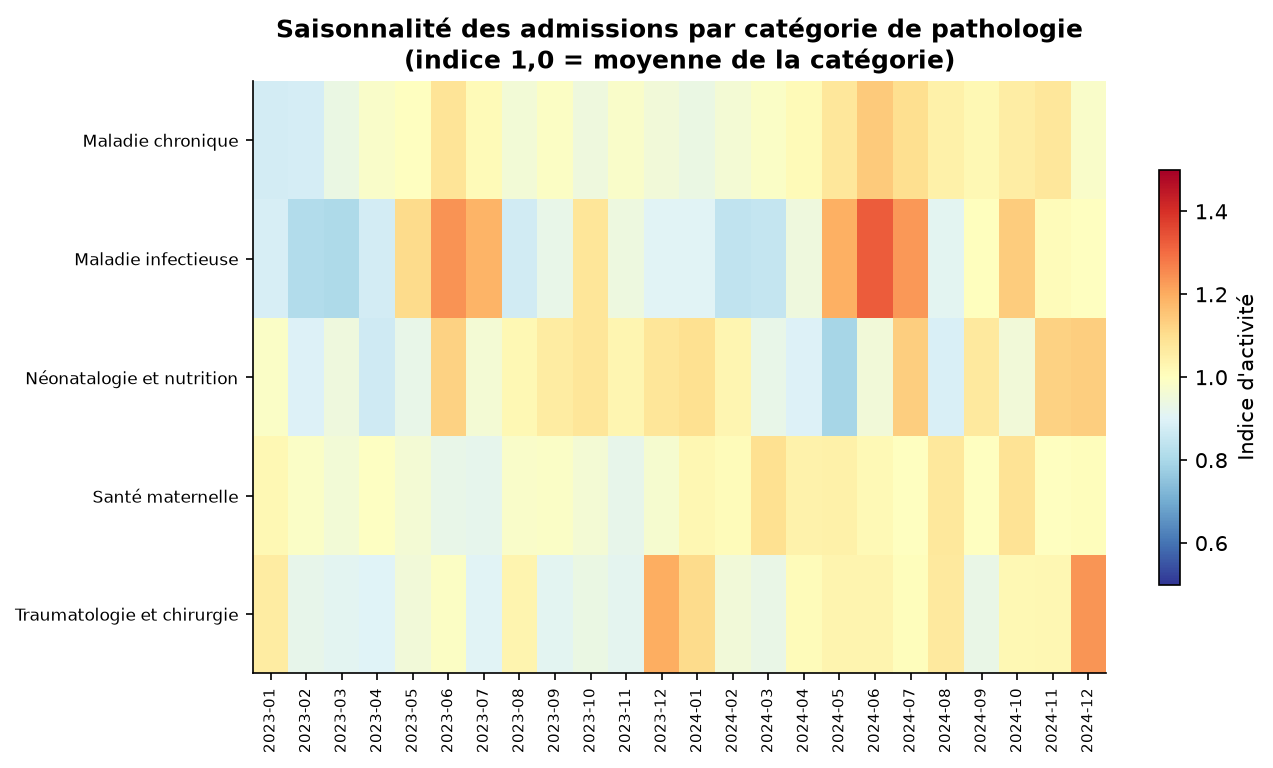

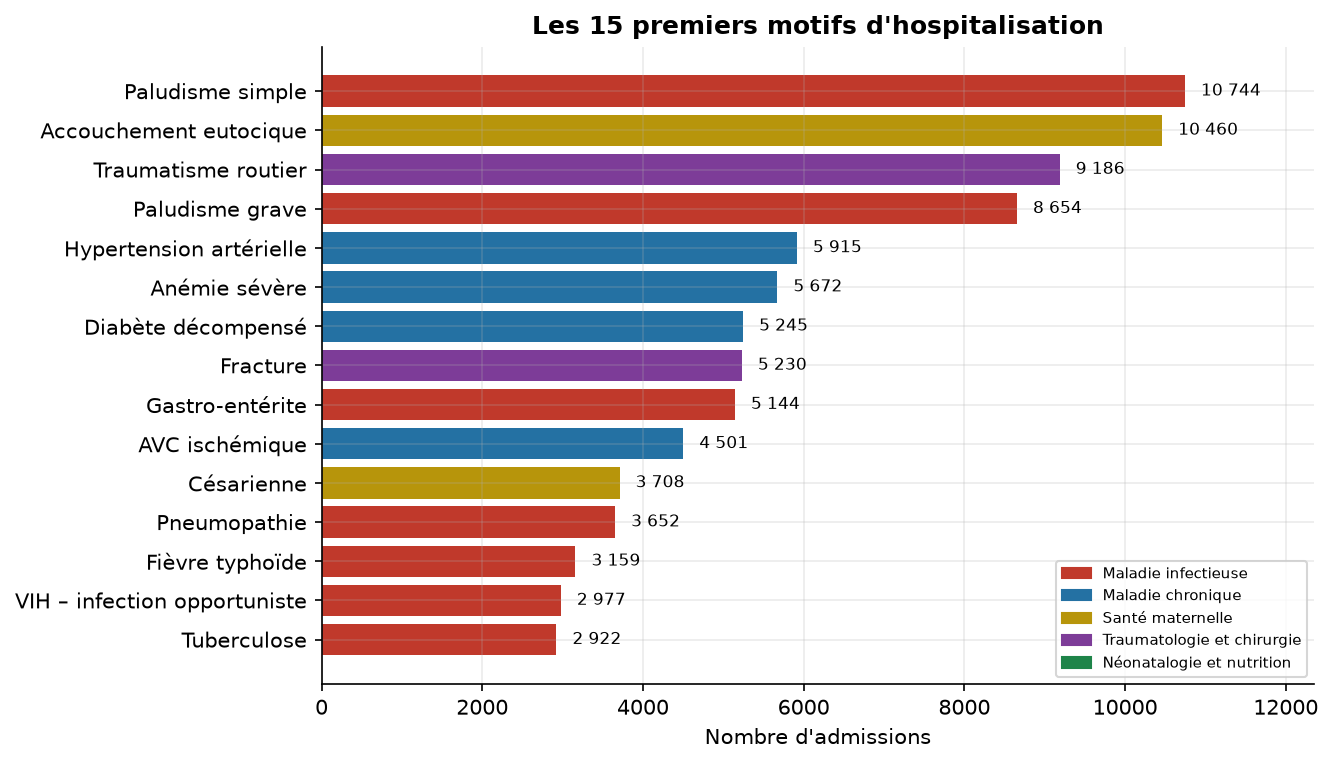

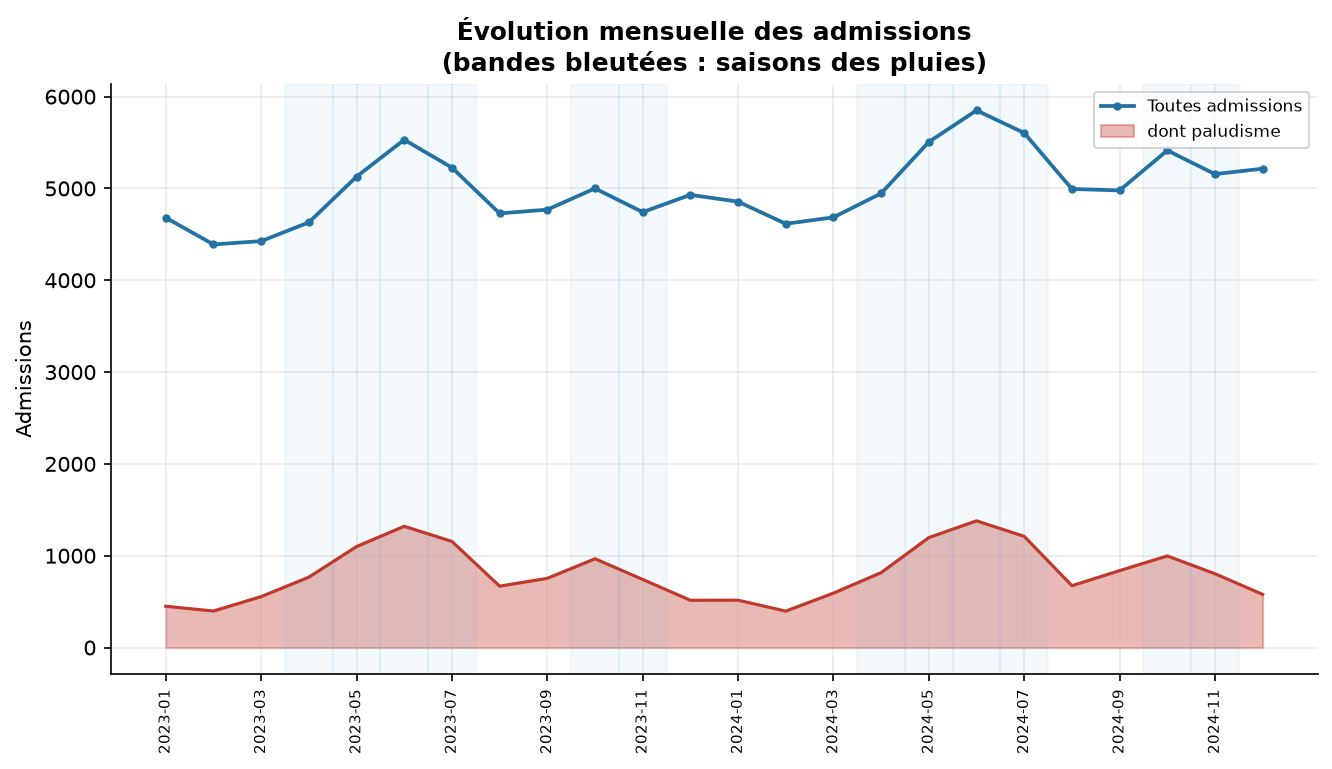

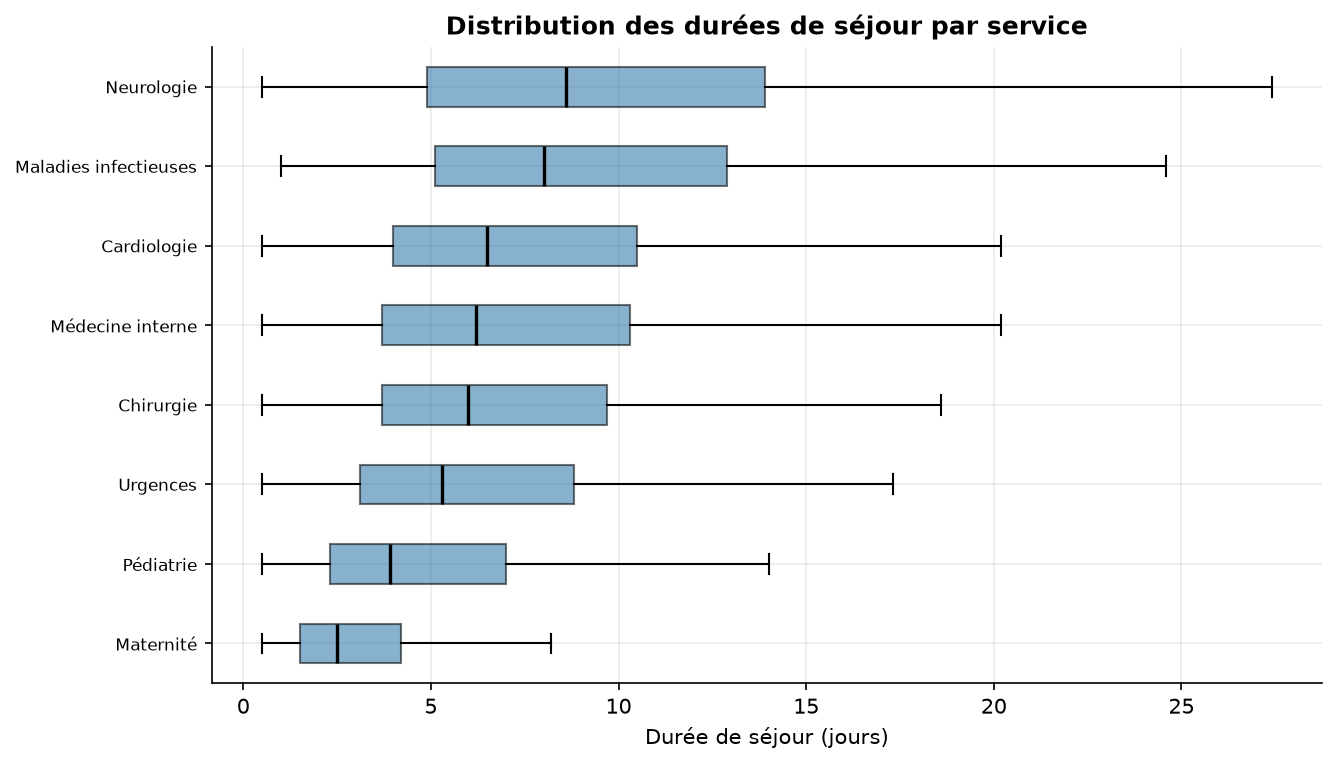

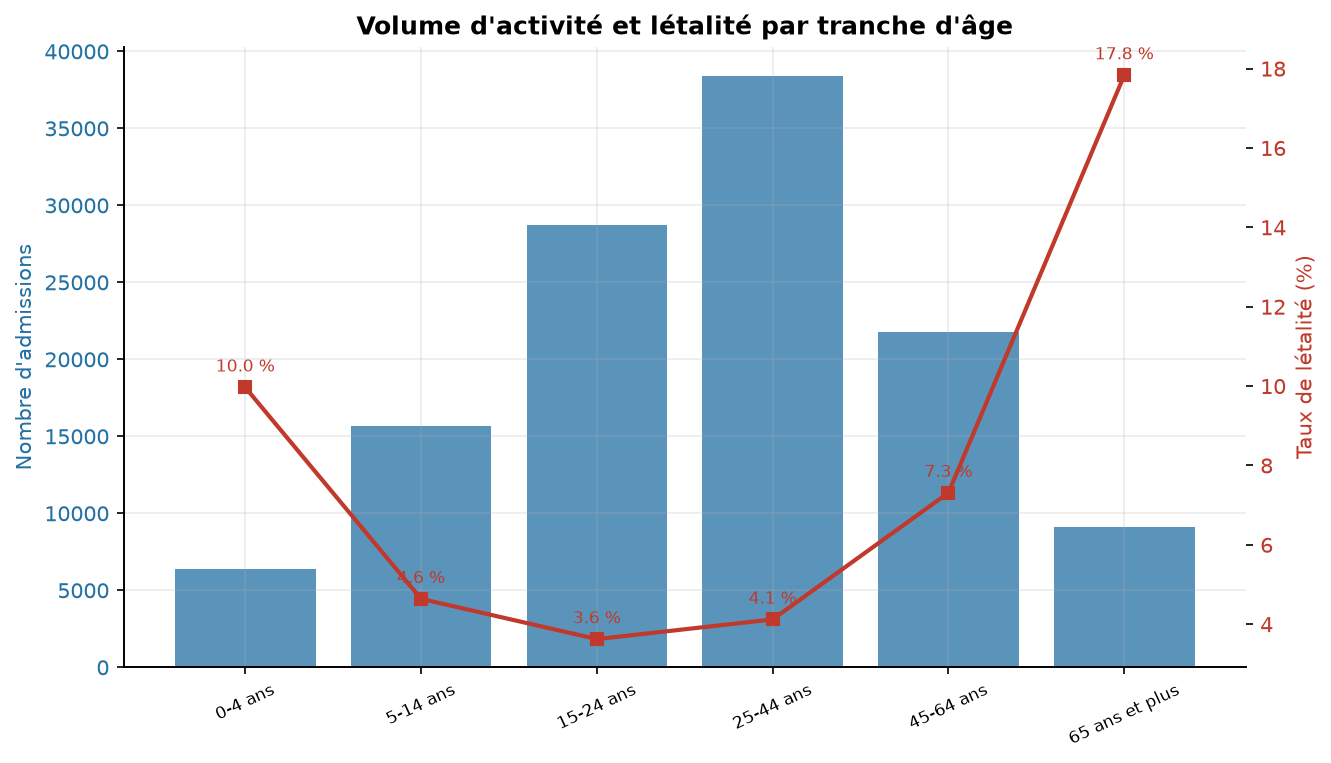

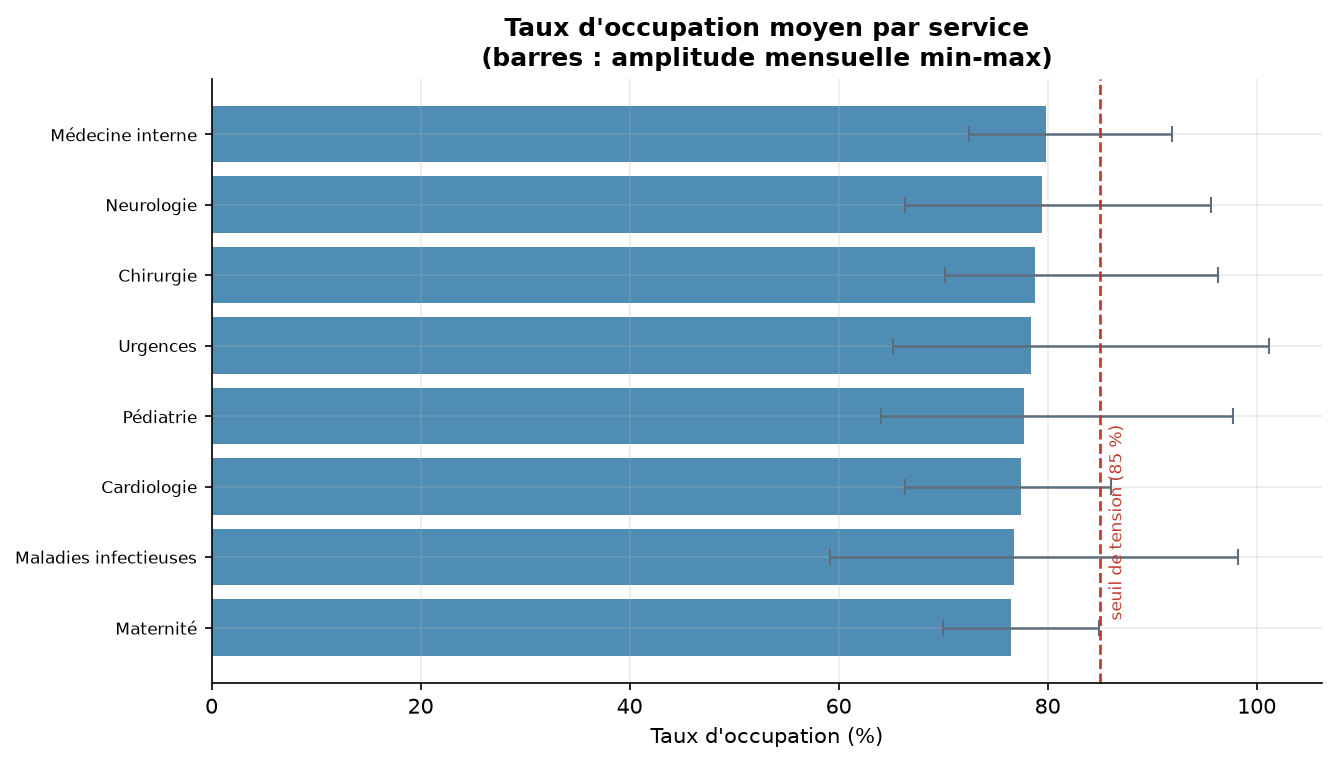

In [28]:
from IPython.display import Image, display

for chemin in sorted(fichiers)[1:]:
    display(Image(filename=chemin, width=760))

---
# 10. Synthèse et indicateurs clés

In [29]:
kpi = {
    "Lignes en entrée": f"{len(df_brut):,}",
    "Lignes chargées après nettoyage": f"{len(faits):,}",
    "Patients distincts (pseudonymisés)": f"{faits['id_patient_pseudo'].nunique():,}",
    "Période couverte": f"{dimensions['dim_date']['date_jour'].min():%d/%m/%Y} "
                        f'→ {dimensions["dim_date"]["date_jour"].max():%d/%m/%Y}',
    "Tables de l'entrepôt": f"{len(dimensions)} dimensions + 1 table de faits",
    "Règles de qualité satisfaites":
        f"{(rapport_qualite['statut'] == 'OK').sum()}/{len(rapport_qualite)}",
    "Durée moyenne de séjour": f"{faits['duree_sejour_j'].mean():.1f} jours",
    "Taux de létalité global":
        f"{100 * faits.merge(dimensions['dim_issue'], on='issue_id')['est_deces'].mean():.2f} %",
    "Part du paludisme dans les admissions":
        f"{100 * df_enrichi['pathologie'].str.startswith('Paludisme').mean():.1f} %",
    "Taux de réadmission à 30 jours":
        f"{100 * faits['est_readmission_30j'].mean():.2f} %",
}
pd.Series(kpi, name="valeur").to_frame()

,valeur
Lignes en entrée,"122,400"
Lignes chargées après nettoyage,"120,000"
Patients distincts (pseudonymisés),"96,286"
Période couverte,01/01/2023 → 31/12/2024
Tables de l'entrepôt,6 dimensions + 1 table de faits
Règles de qualité satisfaites,7/8
Durée moyenne de séjour,6.9 jours
Taux de létalité global,6.00 %
Part du paludisme dans les admissions,16.2 %
Taux de réadmission à 30 jours,2.07 %


## Ce que le pipeline a produit

**Sur la qualité des données.** L'export brut du SIH n'était pas exploitable en
l'état : la seule normalisation des libellés a ramené la colonne `pathologie` de
plus de cent modalités apparentes à ses 31 diagnostics réels. Toute analyse
menée directement sur le fichier source aurait été fausse sans que rien ne le
signale.

**Sur le plan réglementaire.** Les données identifiantes ont été retirées avant
tout chargement, et le journal d'audit chargé dans l'entrepôt documente chaque
traitement appliqué. Le hachage déterministe préserve le chaînage des séjours,
ce qui permet de calculer un taux de réadmission — un indicateur qu'une
anonymisation par suppression aurait rendu inaccessible.

**Sur le plan épidémiologique.** Le paludisme domine l'activité et suit
strictement le calendrier des pluies. Les pics d'admission de l'établissement ne
sont donc pas aléatoires : ils sont prévisibles plusieurs semaines à l'avance,
ce qui ouvre la voie à un dimensionnement anticipé des stocks et des équipes.